# Redes Neuronales para Bank Marketing

Este notebook aplica una red neuronal tipo **Multilayer Perceptron (MLP)** al problema de clasificación binaria del dataset Bank Marketing: predecir si un cliente aceptará o no un depósito a plazo (`y`).

## 1. Introducción al Modelo

Una red neuronal artificial es un modelo compuesto por capas de unidades conectadas entre sí. En este notebook usamos un **MLPClassifier**, una red neuronal feed-forward con capas densas. Cada neurona combina variables de entrada, aplica una función de activación y pasa la información hacia la siguiente capa.

**En qué casos se usa:**

- Clasificación binaria o multiclase.
- Problemas donde puede haber relaciones no lineales entre variables.
- Datos tabulares ya convertidos a formato numérico.
- Escenarios donde se quiere comparar un modelo flexible contra modelos lineales o árboles.

**Por qué podría servir en este caso:**

El dataset Bank Marketing contiene variables demográficas, financieras y de historial de contacto. Es posible que la decisión de aceptar un depósito no dependa de una sola variable, sino de combinaciones no lineales entre edad, balance, campaña, historial previo, tipo de contacto y resultado de campañas anteriores. Una red neuronal puede capturar parte de esas interacciones, siempre que se controle el sobreajuste y se evalúe con métricas adecuadas para clases desbalanceadas.

## 2. Configuración e Importaciones

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from data.loader import load_bank_data
from src.features.build_features import BankFeatureEngineer

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

## 3. Prevención de Data Leakage y Carga de Datos

La variable `duration` representa la duración de la llamada. Esa información solo se conoce durante o después del contacto, así que usarla antes de llamar produciría **data leakage**: el modelo aprendería con información que no estaría disponible en producción.

Por eso cargamos los datos con `drop_duration=True`. Además, el conjunto de prueba se separa antes del entrenamiento y se usa `stratify=y` para conservar la proporción de la clase positiva.

In [2]:
if "load_bank_data" not in globals():
    import sys
    from pathlib import Path

    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.append(str(PROJECT_ROOT))

    from data.loader import load_bank_data

X, y = load_bank_data(drop_duration=True)

print(f"Dimensiones de X: {X.shape}")
print(f"Distribución del target:\n{y.value_counts(normalize=True).rename({0: 'no', 1: 'yes'}) * 100}")
display(X.head())

Descargando el dataset 'Bank Marketing' (ID 222)...


Variable 'duration' omitida correctamente.
Dimensiones de X: (45211, 15)
Distribución del target:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,1,-1,0,NaN


In [3]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=SEED,
    stratify=y_temp,
)

print(f"Train: {X_train.shape}")
print(f"Validación: {X_val.shape}")
print(f"Test: {X_test.shape}")

Train: (27126, 15)
Validación: (9042, 15)
Test: (9043, 15)


## 4. Feature Engineering

Se reutiliza `BankFeatureEngineer`, el transformador personalizado del proyecto. Este paso crea variables derivadas como contacto previo, grupos de edad, indicadores sobre el balance y limpieza de `poutcome`.

La ventaja de poner este paso dentro del `Pipeline` es que las transformaciones se ajustan solo con el entrenamiento durante validación cruzada. Así evitamos que información del conjunto de validación o prueba influya en el proceso de entrenamiento.

In [4]:
feature_engineer = BankFeatureEngineer()
X_train_fe_preview = feature_engineer.fit_transform(X_train)

new_columns = sorted(set(X_train_fe_preview.columns) - set(X_train.columns))
print("Nuevas columnas creadas:")
print(new_columns)

display(X_train_fe_preview.head())

Nuevas columnas creadas:
['contacted_before', 'has_high_balance', 'has_negative_balance', 'has_previous_contact', 'is_senior', 'is_young', 'poutcome_clean']


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,...,campaign,pdays,previous,contacted_before,has_previous_contact,is_senior,is_young,has_negative_balance,has_high_balance,poutcome_clean
10333,43,services,married,secondary,no,2478,yes,no,NaN,12,...,1,NaN,0,0,0,0,0,0,0,NaN
9723,40,blue-collar,married,primary,no,676,no,no,NaN,9,...,1,NaN,0,0,0,0,0,0,0,NaN
22764,39,technician,married,secondary,no,3825,no,yes,cellular,25,...,6,NaN,0,0,0,0,0,0,0,NaN
23223,42,technician,divorced,secondary,no,324,yes,no,cellular,27,...,2,NaN,0,0,0,0,0,0,0,NaN
5594,31,blue-collar,married,secondary,no,631,yes,no,NaN,23,...,4,NaN,0,0,0,0,0,0,0,NaN


## 5. Preprocesado de Datos

Las redes neuronales son sensibles a la escala de las variables. Por eso las variables numéricas pasan por imputación con mediana y `StandardScaler`. Las variables categóricas pasan por imputación constante y `OneHotEncoder`.

El preprocesador se construye después de aplicar una vista previa del feature engineering para detectar correctamente columnas numéricas y categóricas.

In [5]:
numeric_features = X_train_fe_preview.select_dtypes(include=["int64", "int32", "float64", "float32"]).columns.tolist()
categorical_features = X_train_fe_preview.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", one_hot_encoder),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'balance', 'day_of_week', 'campaign',
                                  'pdays', 'previous', 'contacted_before',
                                  'has_previous_contact', 'is_senior',
                                  'is_young', 'has_negative_balance',
                                  'has_high_balance']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['job', 'marital', 'education', 'default',
                                  'housing', 'loan', 'contact', 'month',
                                  'poutcome_clean'])])

## 6. Modelo de Red Neuronal

Usamos `MLPClassifier` con dos capas ocultas. La salida del modelo es una probabilidad para la clase positiva. Como el dataset está desbalanceado, evaluamos con métricas enfocadas en la clase `yes`: `precision`, `recall`, `f1` y `roc_auc`.

`early_stopping=True` reserva internamente una parte del entrenamiento para monitorear si el modelo deja de mejorar. Esto ayuda a controlar el sobreajuste.

In [6]:
mlp_pipeline = Pipeline(steps=[
    ("engineer", BankFeatureEngineer()),
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=256,
        learning_rate_init=1e-3,
        max_iter=120,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=10,
        random_state=SEED,
        verbose=False,
    )),
])

mlp_pipeline

Pipeline(steps=[('engineer', BankFeatureEngineer()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance',
                                                   'day_of_week', 'campaign',
                                                   'pdays', 'previous',
                                                   'contacted_before',
                                                   'has_previous_contact',
                                                   'is_senior', 'is_young',
                                                   'has_negative_balance',
                                                   'has...
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month',
                                                   'poutcome_clean'])])),
                ('classifier',
                 MLPClassifier(batch_size=256, early_stopping=True,
                               hidden_layer_sizes=(64, 32), max_iter=120,
                               random_state=42, validation_fraction=0.15))])

## 7. Entrenamiento y Validación Cruzada

La validación cruzada se hace solo sobre `X_train`. El conjunto de prueba queda reservado para la evaluación final. Usamos `StratifiedKFold` porque la clase positiva es minoritaria.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    "roc_auc": "roc_auc",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
}

cv_results = cross_validate(
    mlp_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=True,
)

cv_summary = pd.DataFrame({
    metric: [cv_results[f"test_{metric}"].mean(), cv_results[f"test_{metric}"].std()]
    for metric in scoring
}, index=["mean", "std"]).T

display(cv_summary.sort_values("mean", ascending=False))

,mean,std
roc_auc,0.772593,0.005039
precision,0.608556,0.017187
f1,0.287151,0.053099
recall,0.190028,0.042882


Ahora entrenamos el pipeline sobre el conjunto de entrenamiento y validamos contra `X_val`. Esta validación permite revisar el comportamiento antes de tocar el conjunto de prueba.

In [8]:
mlp_pipeline.fit(X_train, y_train)

y_val_pred = mlp_pipeline.predict(X_val)
y_val_proba = mlp_pipeline.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_val_pred, target_names=["no (0)", "yes (1)"], zero_division=0))
print(f"ROC-AUC validación: {roc_auc_score(y_val, y_val_proba):.4f}")

              precision    recall  f1-score   support

      no (0)       0.90      0.99      0.94      7984
     yes (1)       0.68      0.18      0.28      1058

    accuracy                           0.89      9042
   macro avg       0.79      0.58      0.61      9042
weighted avg       0.87      0.89      0.87      9042

ROC-AUC validación: 0.7893


## 8. Curvas de Aprendizaje

Las curvas de aprendizaje muestran cómo cambia el desempeño al aumentar el tamaño del conjunto de entrenamiento. Si el score de entrenamiento es alto y el de validación bajo, hay sobreajuste. Si ambos son bajos, puede haber subajuste o falta de señal en las variables.

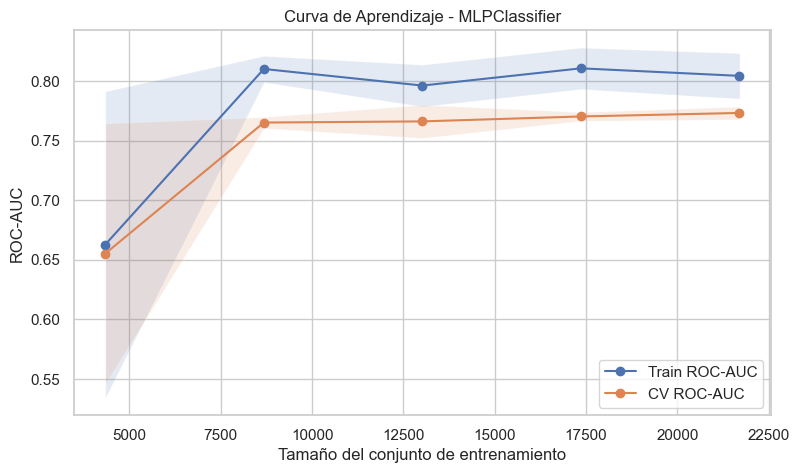

,train_size,train_mean,train_std,val_mean,val_std
0,4340,0.662746,0.128526,0.655174,0.109303
1,8680,0.810071,0.011022,0.765107,0.004649
2,13020,0.796158,0.017490,0.766077,0.013871
3,17360,0.810607,0.017339,0.770220,0.003599
4,21700,0.804291,0.019037,0.773164,0.005317


In [9]:
train_sizes, train_scores, val_scores = learning_curve(
    mlp_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1,
)

learning_df = pd.DataFrame({
    "train_size": train_sizes,
    "train_mean": train_scores.mean(axis=1),
    "train_std": train_scores.std(axis=1),
    "val_mean": val_scores.mean(axis=1),
    "val_std": val_scores.std(axis=1),
})

plt.figure(figsize=(9, 5))
plt.plot(learning_df["train_size"], learning_df["train_mean"], marker="o", label="Train ROC-AUC")
plt.plot(learning_df["train_size"], learning_df["val_mean"], marker="o", label="CV ROC-AUC")
plt.fill_between(
    learning_df["train_size"],
    learning_df["train_mean"] - learning_df["train_std"],
    learning_df["train_mean"] + learning_df["train_std"],
    alpha=0.15,
)
plt.fill_between(
    learning_df["train_size"],
    learning_df["val_mean"] - learning_df["val_std"],
    learning_df["val_mean"] + learning_df["val_std"],
    alpha=0.15,
)
plt.title("Curva de Aprendizaje - MLPClassifier")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("ROC-AUC")
plt.legend()
plt.show()

display(learning_df)

## 9. Convergencia del Modelo

La curva de pérdida (`loss_curve_`) muestra si la red neuronal está aprendiendo durante las iteraciones. Una pérdida que baja y luego se estabiliza indica convergencia razonable. Si la pérdida oscila demasiado o no baja, puede ser necesario ajustar la tasa de aprendizaje, arquitectura, regularización o número de iteraciones.

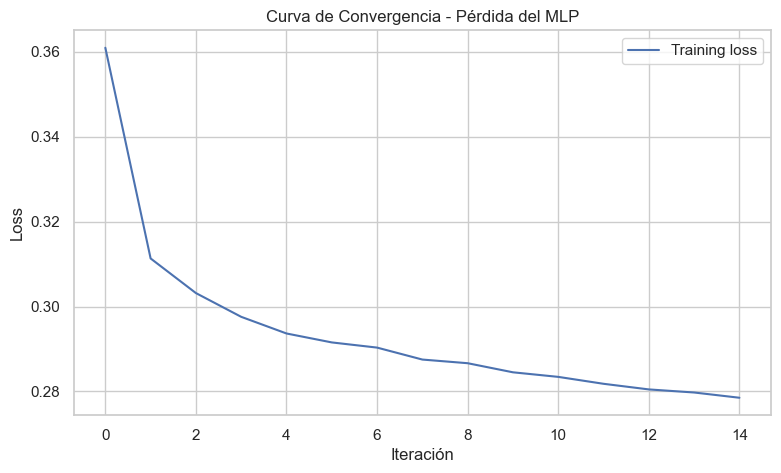

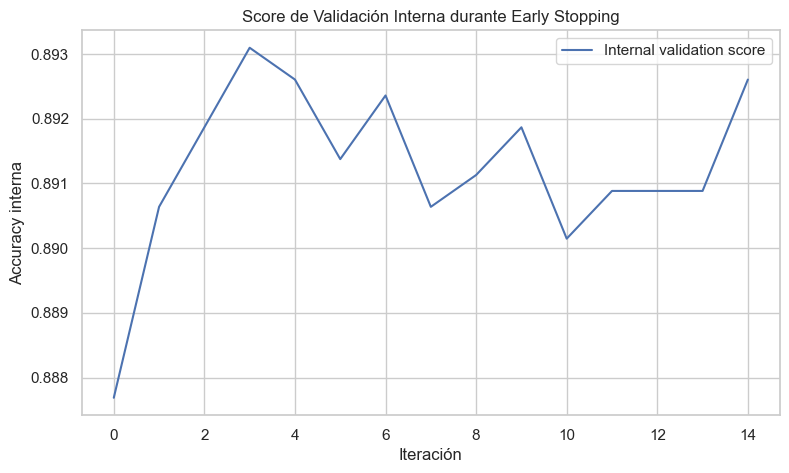

Iteraciones ejecutadas: 15
Loss final: 0.2785


In [10]:
trained_mlp = mlp_pipeline.named_steps["classifier"]

plt.figure(figsize=(9, 5))
plt.plot(trained_mlp.loss_curve_, label="Training loss")
plt.title("Curva de Convergencia - Pérdida del MLP")
plt.xlabel("Iteración")
plt.ylabel("Loss")
plt.legend()
plt.show()

if hasattr(trained_mlp, "validation_scores_"):
    plt.figure(figsize=(9, 5))
    plt.plot(trained_mlp.validation_scores_, label="Internal validation score")
    plt.title("Score de Validación Interna durante Early Stopping")
    plt.xlabel("Iteración")
    plt.ylabel("Accuracy interna")
    plt.legend()
    plt.show()

print(f"Iteraciones ejecutadas: {trained_mlp.n_iter_}")
print(f"Loss final: {trained_mlp.loss_:.4f}")

## 10. Evaluación Final en Test

El test se usa una sola vez al final. Esta evaluación estima cómo podría comportarse el modelo con datos no vistos.

In [11]:
y_test_pred = mlp_pipeline.predict(X_test)
y_test_proba = mlp_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_test_pred, target_names=["no (0)", "yes (1)"], zero_division=0))
print(f"ROC-AUC test: {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"F1 clase positiva: {f1_score(y_test, y_test_pred):.4f}")
print(f"Precision clase positiva: {precision_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"Recall clase positiva: {recall_score(y_test, y_test_pred):.4f}")

              precision    recall  f1-score   support

      no (0)       0.90      0.99      0.94      7985
     yes (1)       0.66      0.17      0.27      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.58      0.60      9043
weighted avg       0.87      0.89      0.86      9043

ROC-AUC test: 0.7847
F1 clase positiva: 0.2659
Precision clase positiva: 0.6617
Recall clase positiva: 0.1664


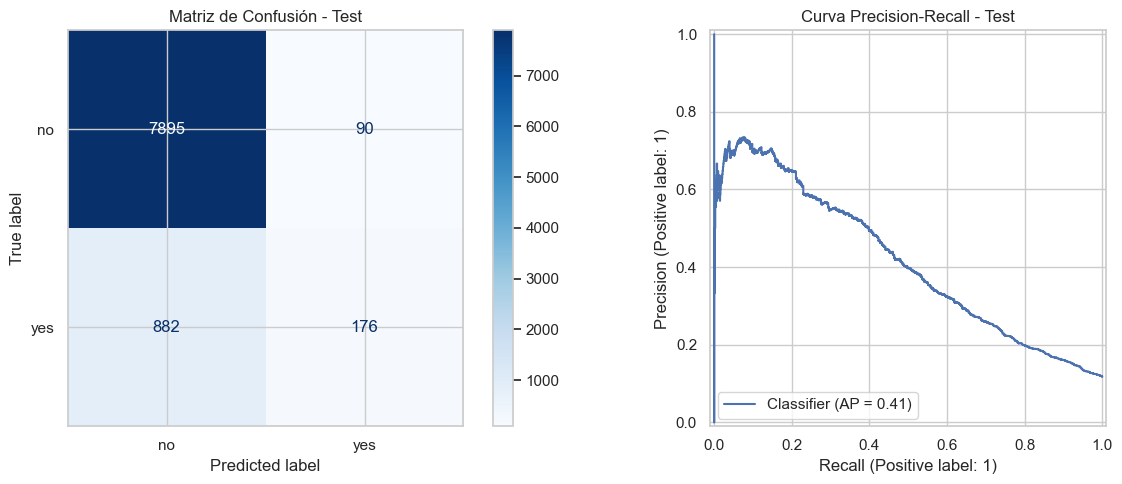

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["no", "yes"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Matriz de Confusión - Test")

PrecisionRecallDisplay.from_predictions(y_test, y_test_proba, ax=axes[1])
axes[1].set_title("Curva Precision-Recall - Test")

plt.tight_layout()
plt.show()

## 11. Comparación Final: Red Neuronal vs Baseline

En el baseline se usó un `DummyClassifier` como baseline. Ese modelo predice siempre la clase mayoritaria (`no` / `0`), por lo que puede obtener un accuracy aparentemente alto debido al desbalance, pero normalmente tiene desempeño nulo sobre la clase positiva (`yes` / `1`).

La comparación final debe enfocarse especialmente en `recall`, `precision`, `f1` y `roc_auc` para la clase positiva, porque el objetivo real es identificar clientes con mayor probabilidad de aceptar el depósito.

In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline = DummyClassifier(strategy="most_frequent", random_state=SEED)
baseline.fit(X_train, y_train)

y_baseline_pred = baseline.predict(X_test)
y_baseline_proba = baseline.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame([
    {
        "modelo": "Baseline Notebook 01 - DummyClassifier",
        "accuracy": accuracy_score(y_test, y_baseline_pred),
        "precision_yes": precision_score(y_test, y_baseline_pred, zero_division=0),
        "recall_yes": recall_score(y_test, y_baseline_pred),
        "f1_yes": f1_score(y_test, y_baseline_pred),
        "roc_auc": roc_auc_score(y_test, y_baseline_proba),
    },
    {
        "modelo": "Red Neuronal - MLPClassifier",
        "accuracy": accuracy_score(y_test, y_test_pred),
        "precision_yes": precision_score(y_test, y_test_pred, zero_division=0),
        "recall_yes": recall_score(y_test, y_test_pred),
        "f1_yes": f1_score(y_test, y_test_pred),
        "roc_auc": roc_auc_score(y_test, y_test_proba),
    },
])

display(comparison.round(4))

,modelo,accuracy,precision_yes,recall_yes,f1_yes,roc_auc
0,Baseline Notebook 01 - DummyClassifier,0.8830,0.0000,0.0000,0.0000,0.5000
1,Red Neuronal - MLPClassifier,0.8925,0.6617,0.1664,0.2659,0.7847


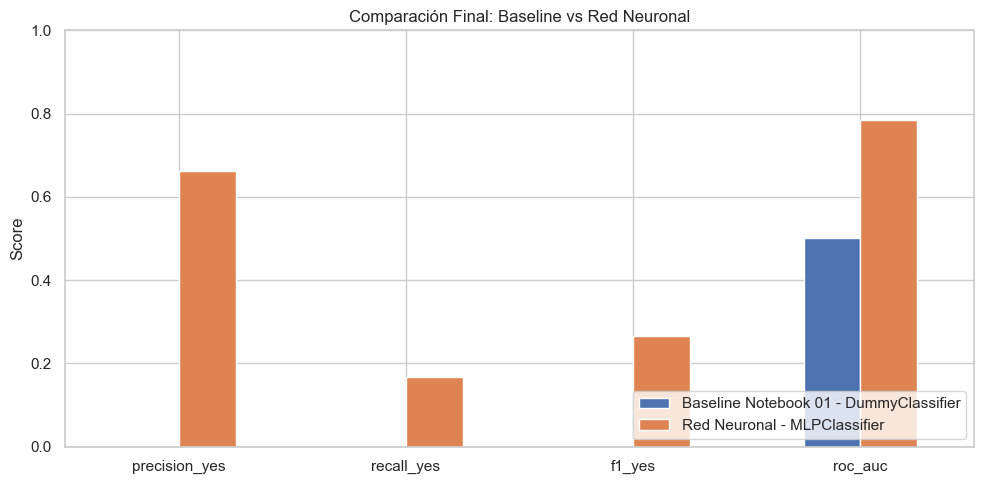

In [14]:
comparison_plot = comparison.set_index("modelo")[["precision_yes", "recall_yes", "f1_yes", "roc_auc"]]

ax = comparison_plot.T.plot(kind="bar", figsize=(10, 5))
ax.set_title("Comparación Final: Baseline vs Red Neuronal")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- El baseline puede tener un accuracy alto porque casi todos los clientes pertenecen a la clase `no`.
- El baseline no identifica clientes `yes`, por eso su `recall_yes`, `precision_yes` y `f1_yes` suelen ser `0`.
- La red neuronal se considera útil si mejora claramente el `f1_yes` y el `roc_auc`, aunque su accuracy global no sea mucho mayor que el baseline.
- Si la red neuronal mejora `roc_auc` pero tiene bajo `recall_yes`, conviene optimizar el umbral de decisión en lugar de usar el corte por defecto de `0.5`.

## 12. Comparacion Redes Neuronales vs Regresión Logística

Al comparar la **red neuronal MLPClassifier** con la **regresión logística**, se observa que ambos modelos superan claramente al baseline, pero se comportan de forma diferente frente a la clase positiva (`yes`).

La **regresión logística** obtuvo un `recall` alto para la clase `yes` (`0.62`), lo que significa que logró encontrar una buena parte de los clientes que realmente aceptan el depósito. Sin embargo, su `precision` fue baja (`0.27`), por lo que también generó muchos falsos positivos: es decir, predijo como interesados a muchos clientes que en realidad no aceptarían.

La **red neuronal**, en cambio, fue más conservadora. Alcanzó una `precision_yes` de `0.6617`, mucho más alta que la regresión logística, pero su `recall_yes` fue bajo (`0.1664`). Esto indica que cuando la red neuronal predice que un cliente aceptará, suele tener mayor certeza, pero deja escapar muchos clientes que sí estaban interesados.

En términos de `roc_auc`, la red neuronal obtuvo `0.7847`, ligeramente superior al `0.7721` de la regresión logística básica. Esto sugiere que la red neuronal tiene una capacidad de separación un poco mejor entre clientes `yes` y `no`, pero esa ventaja no se refleja completamente en el `f1_yes`, porque el recall quedó demasiado bajo.

Desde una perspectiva de negocio, la **regresión logística es mejor si el objetivo es contactar más clientes potencialmente interesados**, aceptando el costo de más falsos positivos. La **red neuronal es mejor si el objetivo es priorizar pocos clientes, pero con mayor probabilidad de conversión**.

## 13. Conclusiones

El modelo de **red neuronal MLPClassifier** logró superar claramente al baseline. El baseline con `DummyClassifier` obtuvo un `accuracy` de `0.8830`, pero esto ocurre porque siempre predice la clase mayoritaria (`no`). Su desempeño real para detectar clientes que sí aceptan el depósito es nulo: `precision_yes = 0`, `recall_yes = 0`, `f1_yes = 0` y `roc_auc = 0.5`.

La red neuronal obtuvo mejores resultados generales: `accuracy = 0.8925`, `precision_yes = 0.6617`, `recall_yes = 0.1664`, `f1_yes = 0.2659` y `roc_auc = 0.7847`. Esto indica que el modelo sí aprendió patrones útiles en los datos, especialmente porque el `roc_auc` está bastante por encima de `0.5`, que sería equivalente a un modelo sin capacidad discriminativa.

Sin embargo, el resultado también muestra una limitación importante: el **recall de la clase positiva es bajo**. El modelo identifica correctamente solo una parte pequeña de los clientes que realmente aceptan el depósito. En otras palabras, cuando la red neuronal predice `yes`, suele hacerlo con buena precisión, pero deja escapar muchos clientes potencialmente interesados.

Esto sugiere que el modelo está siendo conservador: prefiere predecir pocos `yes`, pero con mayor seguridad. Esa estrategia puede ser útil si el banco quiere reducir llamadas innecesarias, pero no es ideal si el objetivo principal es encontrar la mayor cantidad posible de clientes interesados.

La mejora en `precision_yes` frente al baseline es significativa. El baseline nunca identifica clientes positivos, mientras que la red neuronal alcanza una precisión de aproximadamente `66%` para la clase `yes`. Esto significa que, entre los clientes que el modelo marca como posibles aceptantes, una proporción importante realmente acepta.

El `f1_yes = 0.2659` refleja el desequilibrio entre precisión y recall. Aunque la precisión es buena, el recall bajo reduce el F1-score. Por eso, una mejora natural sería ajustar el **umbral de decisión**. En lugar de clasificar como `yes` solo cuando la probabilidad sea mayor a `0.5`, se podría probar un umbral menor para aumentar el recall.

La eliminación de `duration` fue clave para evitar **data leakage**. Esta variable representa información de la llamada que no estaría disponible antes del contacto comercial, por lo que incluirla habría producido métricas artificialmente altas y poco realistas para un caso de uso real.

El preprocesamiento también fue determinante. La red neuronal necesita variables numéricas escaladas para entrenar de forma estable, por eso se aplicó imputación, `StandardScaler` y `OneHotEncoder` dentro de un `Pipeline`. Esto permitió mantener el flujo ordenado y reducir el riesgo de contaminación entre entrenamiento, validación y prueba.